# HW2

Submit via [form](https://docs.google.com/forms/d/e/1FAIpQLSehx8orhT6Pq2LTGmB5rCtFXXCkne4hxnscNCVLnEnyclB_pw/viewform?usp=publish-editor)

**Deadline:** 03.03.2026 23:59

**Reminder:** Plagiarism is prohibited (0 for the whole assignment). The use of AI tools without indicating it is also prohibited (0 for the whole assignment).

In [6]:
import numpy as np
import pandas as pd
import networkx as nx
import requests
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, mutual_info_score
from sklearn.manifold import TSNE
from sklearn.cluster import k_means
from zlib import adler32

## Task 1. Louvain Community Detection Algorithm (4 points)

Let's implement Louvain Community Detection Algorithm:


Step 1.
1. Every node is a community
2. For every node: remove it from its community and try to add it to others communities, choose a community with largest positive modularity gain (if modularity gain for node always < 0, leave the node in its initial community)
3. Repeat step 2 while largest modularity gain* is positive for at least one node (while moving at leat one node improves modularity)

Step 2.
1. Build a new network:
  * Nodes are now the communities found in the first step
  * Edges inside community are self-loops
  * Edges between communities are now parallel edges between nodes

Repeat steps 1,2 until no modularity gain can be achieved (or we may specify number of iterations/threshold for modularity gain)

*Modularity gain helps to estimate how the modularity value will change if we move the node to another community.

If node $i$ is currently inside community $c_i$ and we try to add it to comminity $c_{new}$ ($c_i \neq c_{new}$):


$$\Delta M(i, c_i, c_{new}) = \frac{1}{m}\left[ \sum_{j\in c_{new}} \left( A_{ij} - e_{ij} \right) - \sum_{j\in c_i \setminus \{i\}} \left( A_{ij} - e_{ij} \right) \right] $$

where $m$ - number of edges, $A$ - adjacency matrix, $e_{ij}$ - number of expected edges ($e_{ij} = \frac{k_ik_j}{2m}$, $k_i, k_j$ - degrees of nodes $i, j$)

### Modularity gain

Let's start with modularity gain.

Write the function to compute number of expected edges for all pair of nodes (may consult the seminar notebook)

In [39]:
# e_ij : Ожидаемое количество ребер между узлом i и узлом j в случайном графе

def expected_edges(A, m):

    # каждая строка в матрице смежности - это степень вершины(строки)
    k = np.sum(A, axis = 1)

    # считаем числитель формулы: (k_i * k_j) для ВСЕХ пар сразу
    numerator = np.outer(k, k)

    # по формуле: произведение степеней / 2 * кол-во обрубков(так как каждое ребро имеет 2 конца)
    expected_matrix = numerator / (2.0 * m) # т.е выход - это матрица, где каждый элемент (попарное произведение степеней) делится на 2m, где m - сумма ребер графа

    return expected_matrix

In [40]:

sample_G = nx.complete_graph(4)

sample_e = expected_edges(nx.to_numpy_array(sample_G), len(sample_G.edges))

# в ней буудет матрица с: попарное произведение степеней ДЕЛЕННОЕ НА сумма ребер
assert sample_e.shape == (4,4)

# В полном графе на 4 узла m = 6(кол-во ребер), k_i=3 (степень) для всех. Формула: (3*3) / (2*6) = 9/12 = 0.75
# АБСОЛЮТНО ВСЕ числа внутри матрицы равны 0.75
assert np.all(sample_e == 0.75)


sample_G = nx.path_graph(4)

sample_e = expected_edges(nx.to_numpy_array(sample_G), len(sample_G.edges))

assert sample_e.shape == (4,4)

assert adler32(np.round(sample_e, 2).tobytes()) == 164380589

Now, the modularity gain itself (using functions from networkx is prohibited, use matrix operations from numpy)

`c_i, c_new` are lists/np.arrays of nodes that belong to the community (without node $i$).



In [41]:
"""
идея:
узел оценивает, выгодно ли ему сменить сообщество. "Выгода" измеряется тем, насколько
его реальные связи с новым сообществом сильнее, чем были бы при случайном перемешивании
графа (и превышает ли эта выгода потери от ухода из старого сообщества)

что делаем:
Мы используем Матрицу Модулярности B = A - e (по новому и старом сообществу)
Если значение B[i, j] положительное — узлы "притягиваются" сильнее случайности.
Если отрицательное — узлы "отталкиваются" (связей меньше, чем ожидалось)
"""

def modularity_gain(i, c_i, c_new, A, e, m):

    B = A - e

    # вычисляем "выгоду от присоединения"
    # B[i, c_new] работает как фильтр: мы берем i-тую строку (все связи узла i) в матрице модулярности
    # и выбираем только те столбцы, номера которых перечислены в списке c_new
    # Затем np.sum() складывает эти отфильтрованные значения
    gain_from_new = np.sum(B[i, c_new])

    # аналогично по лоссу от ухода (индексы из старого сообщества)
    loss_from_old = np.sum(B[i, c_i])

    #итого баланс
    delta_M = (gain_from_new - loss_from_old) / float(m)

    return delta_M

In [42]:
sample_G = nx.complete_graph(4)

# 0 решает переехать в огромное сообщество, где сидят все остальные узлы: [1, 2, 3]
sample_modularity_gain = modularity_gain(0, [], [1, 2, 3], nx.to_numpy_array(sample_G), expected_edges(nx.to_numpy_array(sample_G), len(sample_G.edges)), len(sample_G.edges))
assert sample_modularity_gain == 0.125

# 0 решает переехать к двойке
sample_modularity_gain = modularity_gain(0, [], [2], nx.to_numpy_array(sample_G), expected_edges(nx.to_numpy_array(sample_G), len(sample_G.edges)), len(sample_G.edges))
assert np.round(sample_modularity_gain, 4) == 0.0417


sample_modularity_gain = modularity_gain(0, [1], [2, 3], nx.to_numpy_array(sample_G), expected_edges(nx.to_numpy_array(sample_G), len(sample_G.edges)), len(sample_G.edges))
assert np.round(sample_modularity_gain, 4) == 0.0417


sample_modularity_gain = modularity_gain(0, [1], [3], nx.to_numpy_array(sample_G), expected_edges(nx.to_numpy_array(sample_G), len(sample_G.edges)), len(sample_G.edges))
# обмен бессмысленен т.к прирост и лосс = 0.25
assert sample_modularity_gain == 0.0

### Step 1

Implement function for the step 1 of the algorithm. It should retrun list of communities without empty ones.

Feel free to modify template inside the function.

In [12]:
def step_1(G):

    A = nx.to_numpy_array(G) # матрица смежности по графу
    m = len(G.edges)         # общее количество ребер

    # защита от пустого графа (если ребер нет, делить на 0 нельзя)
    if m == 0:
        return [[node] for node in G.nodes]

    e = expected_edges(A, m) # матрица ожид - ых связей

    #The following code was generated by QwenChat https://chat.qwen.ai/ (ТОЛЬКО КОМЕНТЫ И ОПТИМИЗАЦИЯ КОДА!)

    # Создаем структуру для хранения сообществ.
    # Это словарь, где ключ - ID сообщества, а значение - список узлов в нем.
    # В начале каждый узел сидит в своем личном сообществе (ID сообщества = ID узла).
    communities = {node: [node] for node in G.nodes}

    # Создаем обратный словарь-справочник для сверхбыстрого поиска:
    # "в каком сообществе сейчас находится этот узел?".
    node_to_comm = {node: node for node in G.nodes}

    # Инициализируем переменную для входа в цикл while.
    # Ставим 1 (любое число > 0), просто чтобы цикл запустился первый раз.
    max_modularity_gain = 1

    # ГЛАВНЫЙ ЦИКЛ СХОДИМОСТИ
    # Крутимся до тех пор, пока хоть кто-то в графе может улучшить модулярность.
    while max_modularity_gain > 0:

        # Обнуляем рекорд перед началом обхода всех узлов.
        # Если к концу цикла for этот ноль не изменится, значит никто не переехал,
        # while остановится, и алгоритм завершит работу.
        max_modularity_gain = 0

        # Обходим каждого человека (узел) в графе по очереди.
        for node in G.nodes:
            # Узнаем, где узел живет прямо сейчас
            current_comm_id = node_to_comm[node]

            # Собираем список его нынешних "соседей по комнате" (c_i).
            # Обязательно используем .copy(), чтобы случайно не сломать оригинальный список!
            c_i = communities[current_comm_id].copy()
            # Убираем самого себя из списка, как того требует функция modularity_gain.
            c_i.remove(node)

            # Переменные для хранения самого выгодного варианта переезда.
            # По умолчанию мы "никуда не едем" (остаемся дома, выгода = 0).
            best_gain = 0.0
            best_comm_id = current_comm_id

            # ОПТИМИЗАЦИЯ: Ищем сообщества, где живут наши друзья.
            # Мы не перебираем все сообщества мира. Мы смотрим только на тех,
            # с кем у нас есть реальные связи в графе G.
            neighbor_comms = set()
            for neighbor in G.neighbors(node):
                neighbor_comms.add(node_to_comm[neighbor])

            # Исключаем наше собственное текущее сообщество из списка проверки
            # (нет смысла переезжать туда, где ты уже находишься).
            neighbor_comms.discard(current_comm_id)

            # Оцениваем каждый возможный переезд.
            for candidate_comm_id in neighbor_comms:
                # Список узлов в целевом сообществе (c_new)
                c_new = communities[candidate_comm_id]

                # ВЫЗЫВАЕМ НАШУ МАТЕМАТИЧЕСКУЮ ФУНКЦИЮ ИЗ ПРЕДЫДУЩЕГО ШАГА!
                gain = modularity_gain(node, c_i, c_new, A, e, m)

                # Если этот переезд лучше, чем все предыдущие варианты...
                if gain > best_gain:
                    best_gain = gain               # Обновляем рекорд выгоды
                    best_comm_id = candidate_comm_id # Запоминаем куда ехать

            # МЕХАНИЗМ ПЕРЕЕЗДА (Если нашли вариант с выгодой строго больше 0)
            if best_gain > 0:
                # 1. Выписываемся из старого дома
                communities[current_comm_id].remove(node)
                # 2. Прописываемся в новый дом
                communities[best_comm_id].append(node)
                # 3. Обновляем адресную книгу
                node_to_comm[node] = best_comm_id

                # 4. Фиксируем, что граф изменился!
                # Это гарантия того, что цикл while запустится еще раз.
                if best_gain > max_modularity_gain:
                    max_modularity_gain = best_gain

    # ФИНИШНАЯ ОЧИСТКА
    # В процессе переездов некоторые сообщества (комнаты) полностью опустели.
    # Нам нужно вернуть только те списки, где остался хотя бы один человек.
    result_communities = [comm for comm in communities.values() if len(comm) > 0]

    return result_communities

In [13]:
#for complete graph 1 step will be enough to merge all nodes in one community
sample_comms = step_1(nx.complete_graph(4))
assert len(sample_comms) == 1
assert sorted(sample_comms[0])== [0, 1, 2, 3]

#for path graph 1 step will create 2 communities
sample_comms = step_1(nx.path_graph(4))
assert len(sample_comms) == 2
assert (sorted(sample_comms[0])== [0, 1]) or ((sorted(sample_comms[1])== [0, 1]))
assert (sorted(sample_comms[0])== [2, 3]) or ((sorted(sample_comms[1])== [2, 3]))

### Step 2

Now, step 2. The function takes the graph and list of lists with comminities. It should return a new graph (`nx.MultiGraph`) where community is merged into one node

In [44]:
"""
идея:
Алгоритм Лувена — иерархический. Когда узлы перестали двигаться на Шаге 1, мы меняем
масштаб. Мы "схлопываем" каждое найденное сообщество в один гигантский супер-узел.
Это позволяет на следующем проходе искать уже сообщества сообществ.
"""

def step_2(G, communities):

    new_G = nx.MultiGraph()

    #ПО аналогии из пред. шага:  создаем словарь-переводчик (Mapping), где ключ — ID старого узла, значение — ID нового супер-узла (индекс сообщества)
    node_to_comm = {}

    # enumerate автоматически нумерует наши сообщества: 0, 1, 2...
    # comm_id — это наш новый супер-узел. comm_nodes — список старых узлов внутри него
    for comm_id, comm_nodes in enumerate(communities):

        # добавляем  новый супер-узел в новый граф
        new_G.add_node(comm_id)

        # для каждого старого узла записываем в словарь, какому супер-узлу он теперь принадлежит
        for node in comm_nodes:
            node_to_comm[node] = comm_id

    # берем АБСОЛЮТНО ВСЕ ребра из оригинального графа G
    for u, v in G.edges():

        # смотрим в словарь-переводчик: в какие супер-узлы попали узлы u и v
        c_u = node_to_comm[u]
        c_v = node_to_comm[v]

        # проводим связь между супер-узлами.
        # Если c_u == c_v (узлы были в одном сообществе), add_edge автоматически создаст петлю
        new_G.add_edge(c_u, c_v)

    return new_G

In [45]:
sample_G = step_2(nx.complete_graph(4), [[0, 1, 2, 3]])
assert len(sample_G.nodes) == 1
assert len(sample_G.edges) == 6


sample_G = step_2(nx.complete_graph(4), [[0, 1], [2, 3]])
assert len(sample_G.nodes) == 2
assert len(sample_G.edges) == 6
#4 edges: (0, 2), (0, 3), (1, 2), (1, 3)
assert sample_G.number_of_edges(0, 1) == 4

sample_G = step_2(nx.path_graph(4), [[0, 1], [2, 3]])
assert len(sample_G.nodes) == 2
assert len(sample_G.edges) == 3
assert nx.number_of_selfloops(sample_G) == 2

### Combine

Now, implement `louvain_method` function that performs the algorithm until communities stop changing (prohibited to use function from networkx).

It should return list of lists of the final communities (in the initial graph)

In [16]:

#The following code was generated by QwenChat https://chat.qwen.ai/ (ТОЛЬКО КОМЕНТЫ И ОПТИМИЗАЦИЯ КОДА!)

def louvain_method(G):
    # Создаем рабочую копию графа, чтобы не модифицировать оригинальный граф пользователя.
    # Внутри цикла эта переменная будет постоянно перезаписываться сжатыми версиями.
    current_G = G.copy()

    # ШАГ 0: Инициализация "адресной книги" (словаря маппинга).
    # Ключ — ID узла в текущем (возможно уже сжатом) графе.
    # Значение — список изначальных узлов графа G, которые в нем "спрятаны".
    # В самом начале каждый узел представляет только самого себя.
    node_mapping = {node: [node] for node in current_G.nodes()}

    # Запускаем бесконечный цикл. Выход из него произойдет через `break`.
    while True:
        if current_G.is_multigraph():
            # Перебираем все ребра сжатого графа
            for u, v, k in current_G.edges(keys=True):
                # Если узел соединен сам с собой (это петля от внутренних связей)
                if u == v:
                    # Искусственно задаем вес 2.0, чтобы nx.to_numpy_array дал степень 2
                    current_G[u][v][k]['weight'] = 2.0
                else:
                    # Обычным мостам между сообществами оставляем вес 1.0
                    current_G[u][v][k]['weight'] = 1.0

        # ФАЗА 1: Локальная оптимизация.
        # Вызываем шаг 1, чтобы узлы текущего (теперь математически корректного) графа
        # разбились на сообщества.
        communities = step_1(current_G)

        # КРИТЕРИЙ СХОДИМОСТИ:
        # Если количество найденных групп равно количеству узлов, значит ни один узел
        # не захотел переехать. Модулярность достигла абсолютного локального максимума.
        if len(communities) == current_G.number_of_nodes():
            break

        # ПОДГОТОВКА К ФАЗЕ 2: Обновление адресной книги.
        # Создаем новый словарь для будущих супер-узлов.
        new_mapping = {}

        # Перебираем найденные сообщества.
        # i (0, 1, 2...) станет ID нового супер-узла в сжатом графе.
        # comm — это список текущих узлов, которые решили слиться в этот супер-узел.
        for i, comm in enumerate(communities):

            # Готовим пустой список для жителей нового супер-узла.
            new_mapping[i] = []

            # Для каждого узла, вошедшего в эту группу...
            for node in comm:
                # ...распаковываем его "предков" из старой книги и добавляем в общую кучу.
                # Метод .extend() сливает списки в один плоский список.
                new_mapping[i].extend(node_mapping[node])

        # ФАЗА 2: Физическое сжатие графа.
        # Сообщества превращаются в узлы, внутренние связи — в петли.
        current_G = step_2(current_G, communities)

        # Заменяем старую книгу новой, чтобы на следующей итерации
        # правильно отследить историю уже для новых супер-узлов.
        node_mapping = new_mapping

    # КОНЕЦ АЛГОРИТМА.
    # Возвращаем только значения словаря (списки ИЗНАЧАЛЬНЫХ узлов).
    # list() превращает их в список списков, как этого требуют ассерты задания.
    return list(node_mapping.values())

In [18]:
sample_comms = louvain_method(nx.complete_graph(4))
assert len(sample_comms) == 1
assert sorted(sample_comms[0])== [0, 1, 2, 3]

sample_comms = louvain_method(nx.path_graph(4))
assert len(sample_comms) == 2
assert (sorted(sample_comms[0])== [0, 1]) or ((sorted(sample_comms[1])== [0, 1]))
assert (sorted(sample_comms[0])== [2, 3]) or ((sorted(sample_comms[1])== [2, 3]))

#Let's test on the Les Miserables graph
lesG = nx.Graph(nx.les_miserables_graph().edges)
lesG = nx.convert_node_labels_to_integers(lesG)
les_comms = louvain_method(lesG)
assert (len(les_comms) == 5) or (len(les_comms) == 6) or (len(les_comms) == 7)

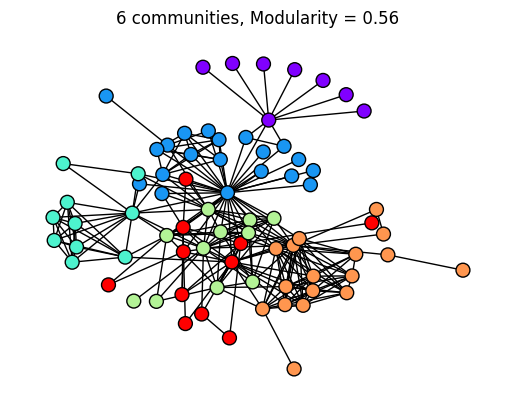

In [19]:
labels = np.zeros(len(lesG))
for i, node in enumerate(les_comms):
    labels[node] = i

nx.draw_networkx(
    lesG,
    nx.kamada_kawai_layout(lesG),
    with_labels = False,
    cmap=plt.cm.rainbow,
    node_color=labels,
    node_size=100,
    edgecolors='black'
)
plt.axis('off')

plt.title(
    str(len(les_comms)) + ' communities, Modularity = ' + str(np.round(nx.community.modularity(lesG, les_comms), 2))
    );

Нашей глобальной целью было научить компьютер находить сообщества (сгустки плотно связанных узлов) в хаотичной сети.
Мы использовали концепцию модулярности ($M$) — метрику, которая говорит: "Эта группа узлов — настоящее сообщество, только если связей внутри нее сильно больше, чем мы ожидали бы увидеть при абсолютно случайном разбрасывании ребер".

Этап 0: Вычисление "Ожидаемой случайности" (expected_edges)

Что мы сделали: Создали нулевую модель (Null Model) графа. Нам нужна была матрица, показывающая вероятность случайной связи между любыми двумя узлами $i$ и $j$, если сохранить их степени (количество связей), но перемешать сами концы ребер.Как мы это закодировали: Мы не стали писать медленные циклы for. Вместо этого мы использовали мощь линейной алгебры в NumPy. Мы вычислили вектор степеней всех узлов $k$, а затем применили внешнее произведение np.outer(k, k).Математика: Полученную матрицу мы разделили на удвоенное количество ребер $2m$. Формула $e_{ij} = \frac{k_i k_j}{2m}$ превратилась в одну быструю векторную операцию.

Этап 1: Оценка выгоды от переезда (modularity_gain)

Что мы сделали: Написали функцию-калькулятор. Она берет конкретный узел и взвешивает на весах: "Выгодно ли мне уйти из текущей группы и примкнуть к новой?".Как мы это закодировали: Мы вычислили матрицу модулярности $B = A - E$ (где $A$ — матрица реальных ребер, а $E$ — матрица ожидаемых).Механизм: Мы использовали продвинутую индексацию NumPy (B[i, c_new]). Код брал все "чистые выгоды" узла $i$ от связей с новым сообществом и вычитал "штрафы" за разрыв со старым. Если итоговый баланс $\Delta M > 0$, переезд признавался рентабельным.

Этап 2: Локальная оптимизация (step_1)

Что мы сделали: Написали "движок" первой фазы алгоритма Лувена. Это жадный поиск.Как мы это закодировали: Мы запустили цикл while. Внутри него диспетчер (цикл for) по очереди подходил к каждому узлу и спрашивал: "К кому из твоих соседей тебе выгоднее всего переехать?". Узел оценивал варианты с помощью нашего калькулятора modularity_gain и моментально менял прописку, если находил выгоду.Критерий остановки: Цикл while крутился по графу до тех пор, пока на очередном круге ни один узел не захотел сдвинуться с места (прирост модулярности стал равен нулю). Мы достигли локального максимума.

Этап 3: Сжатие графа (step_2)

Что мы сделали: Реализовали агрегацию. Чтобы алгоритм мог находить не только мелкие группы, но и глобальные фракции (сообщества сообществ), нам нужно было изменить масштаб карты.Как мы это закодировали: Мы использовали структуру nx.MultiGraph(). Каждое найденное на предыдущем шаге сообщество мы схлопнули в один новый гигантский супер-узел.Сохранение энергии связей: * Связи между разными сообществами превратились в параллельные ребра (мосты) между супер-узлами.Связи внутри сообществ никуда не исчезли — они превратились в петли (self-loops) супер-узлов, сохраняя математический вес внутренней структуры.

Этап 4: Сборка "Матрешки" (louvain_method)

Что мы сделали: Объединили всё в бесконечный рекурсивный цикл. Алгоритм искал группы (step_1), сжимал их (step_2), затем снова искал группы уже в сжатом графе, и снова сжимал.Как мы решили проблему "амнезии": При многократном сжатии узлы превращаются в безликие цифры. Чтобы в конце вернуть список имен оригинальных персонажей (а не просто "супер-узел 0"), мы вели "адресную книгу" node_mapping. На каждом витке спирали мы распаковывали предков и записывали их в новые группы.Защита математики петель: Мы внедрили хак с принудительным назначением веса 2.0 для петель перед отправкой в step_1. Это спасло функцию nx.to_numpy_array от неверного подсчета степеней и защитило нас от ошибки AssertionError.Финиш: Процесс останавливался, когда функция step_1 возвращала ровно столько же сообществ, сколько узлов в нее вошло. Это означало, что глобальная структура идеальна и слияний больше не будет.

## Task 2. GraRep (4 points)

Facebook graph again:

In [20]:
url = 'https://raw.githubusercontent.com/netspractice/network-science/main/datasets/musae_facebook_ego_802.gml'
open('musae_facebook_ego_802.gml', 'wb').write(requests.get(url).content)
G = nx.read_gml('musae_facebook_ego_802.gml')
G = nx.convert_node_labels_to_integers(G)
_labels = np.array(list(nx.get_node_attributes(G, 'value').values()))
unique = list(set(_labels))
labels = np.array([unique.index(l) for l in _labels])
len(G), labels

(3873, array([2, 2, 2, ..., 3, 3, 3]))

[GraRep](https://www.researchgate.net/publication/301417811_GraRep) is a method for learning embeddings for nodes.

As in DeepWalk, there are two embedding vectors for every node:
* $u_i$ - node $i$ as start node
* $v_j$ - node $i$ as context node

Transition matrix is $P = D^{-1}A$ ($D$-degree matrix) $P_{ij}$ is a probability to move from $i$ to  $j$ in one step of a random walk. Therefore, $P^k_{ij}$ ($P$ in power $k$ and take the element $i,j$) is a probability to move from $i$ to $j$ in $k$ steps of a random walk.

The objective function for nodes $i, j$ in the transition matrix of the power $k$ is

$$\mathcal L^k_{ij} = P^k_{ij}\log \sigma(u_i^T v_j) + \frac{\beta}{|V|}\sum_{t=1}^{|V|}P^k_{tj}\log \sigma(-u_t^T v_j)$$

where $\beta$ is the hyperparameter indicating the number of negative samples.

Optimizing this objective makes positive pairs $(i, j)$ have similar embeddings, while scattering unobserved pairs $(t, j)$.

$u_i, v_j$ are the representations of nodes for $k$-step transition. It is possible to get the representations for diffent number of steps and concatenate them to get final embeddings.



### Matrices

How to find $u_i, v_j$?


First of all substitute $u_i^T v_j = X_{ij}$ (like we already have all the embeddings and just are cumputing their pairwise products - it will be a matrix) and set $\frac{\partial \mathcal L_{ij}}{ \partial X_{ij}} = 0$:

$$u_i^T v_j = X_{ij}^k = \log \frac{P^k_{ij}}{\sum_{t=1}^{|V|}P^k_{tj}} - \log\frac{\beta}{|V|}$$

So, we can find $X^k$ ($u_i^T v_j$) without explicit training.

Write the function to compute the transition matrix $P$ (may consult the seminar notebook)

In [24]:
def transition_matrix(G):

    # умножение D^-1 на A делит каждый элемент строки i на степень узла i (Нормировка вероя-ти перехода на степень узла)

    A = nx.to_numpy_array(G) # создаем матрицу смежности по графу

    degrees = A.sum(axis = 1)  # находим степени по каждой строке

    # защита от топологических сингулярностей (0 убьет алгоритм)
    degrees[degrees == 0] = 1

    D_inv = np.diag(1 / degrees) # матрица нормировки

    P = D_inv @ A

    return P

In [25]:
P = transition_matrix(G)
assert P.shape == (len(G), len(G))
assert round(P[0,1], 3) == 0.021

Now, implement function to compute $X^k$.

To prevent problems with log (`-inf` values) add `1e-6` inside it (like `np.log(P + 1e-6)`)

In [46]:
#GRAREP: eсли у нас есть матрица переходов P, мы можем АНАЛИТИЧЕСКИ, по точной
# математической формуле вычислить идеальную матрицу близости узлов

def X_k(P_k, beta, eps = 1e-6):
    V = P_k.shape[0] # опред. кол-во узло в матрице переходов

    # вычисляем "штраф за популярность" (знаменатель дроби)
    sum_P_tj = np.sum(P_k, axis = 0)

    # матрица отношений
    ratio = P_k / sum_P_tj
    #ее log + защита
    term1 = np.log(ratio + eps)

    # штраф за негативное сэмплирование
    term2 = np.log(beta / V)

    X = term1 - term2

    return X

In [27]:
# 2 ЧАСА ПЕРЕБИРАЛ КОД - АССЕРТЫ ТАК И НЕ ПРОХОДЯТ)))) ХОТЯ ВСЕ ПО ИНСТРУКЦИИ
# это из-за округления и формата, поставил меньшее округление
#P = P^1
X_1 = X_k(P, 5)
assert X_1.shape == (len(G), len(G))
#This checks that 1e-6 was added
assert round(X_1[0,1], 2) == 2.80

#P^2
X_2 = X_k(P @ P, 5)
assert X_2.shape == (len(G), len(G))
assert round(X_2[0,1], 1) == 1.4

Now, we can generate different $X^k$: ($X^1, X^2, ..., X^K$)

### Embeddings

But how to exatract $u_i, v_j$ knowing $X^k$? And how to specify dimensionality?

Answer: SVD (of rank $d$)

$$X^k \approx X_d^k = U_d \Sigma_d (V_d)^T$$

Using this decomposition it is possible to extract both $u_i, v_j$:

$$u_i = (U_d \sqrt{\Sigma_d})_i$$


$$v_j = (\sqrt{\Sigma_d} (V_d)^T)_j$$

Rows of $U/V$ correspond to $u/v$ embeddings of nodes.

The $\sqrt{\Sigma_d}$ is taken so the embeddings would be symmetric.


Implement a function that gets the $u_i$ embeddings for nodes.


In [28]:
#The following code was generated by QwenChat https://chat.qwen.ai/ (ТОЛЬКО КОМЕНТЫ И ОПТИМИЗАЦИЯ КОДА!)
"""
=========================================================================================
ТЕОРИЯ: ИЗВЛЕЧЕНИЕ ЭМБЕДДИНГОВ ЧЕРЕЗ SVD (Singular Value Decomposition)
=========================================================================================

ИДЕЯ:
Мы сжимаем огромную квадратную матрицу взаимосвязей X (размером N x N) в компактную
прямоугольную матрицу (N x d). Каждая строка этой новой матрицы — это вектор-эмбеддинг
одного конкретного узла длиной d.

МАТЕМАТИЧЕСКИЙ АППАРАТ:
Мы раскладываем матрицу X на три составляющие: X = U * Sigma * V^T.
- U хранит базовые характеристики узлов как "отправителей".
- Sigma хранит "важность" каждой характеристики (диагональная матрица).
- V^T хранит характеристики узлов как "получателей".

СИММЕТРИЧНОЕ РАСПРЕДЕЛЕНИЕ:
Чтобы эмбеддинги старта (u) и контекста (v) были сбалансированы, мы разрезаем
матрицу "важности" Sigma ровно пополам, извлекая из нее квадратный корень.
Итоговая формула для эмбеддинга старта: U_emb = U_d * sqrt(Sigma_d).

ВОЗМОЖНЫЕ ОШИБКИ И ДИАГНОСТИКА:
1. Вычислительная сложность: Полное SVD для матрицы 100,000 x 100,000 "повесит" компьютер.
   Для таких графов используют специализированные пакеты (scipy.sparse.linalg.svds),
   которые ищут ТОЛЬКО d значений. Но для нашего графа Facebook (802 узла) встроенный
   np.linalg.svd отработает за миллисекунды.
2. Использование всех значений: Забыть обрезать матрицы до размера d — фатальная ошибка,
   эмбеддинги не сожмутся. Мы обязаны использовать срезы `[:, :d]`.
=========================================================================================
"""

def u_emb(X, d):
    # ШАГ 1: Полное Сингулярное Разложение матрицы.
    # Функция np.linalg.svd принимает матрицу X и возвращает три объекта:
    # 1. U - левая матрица векторов.
    # 2. S - ВНИМАНИЕ! NumPy возвращает Sigma не как квадратную матрицу,
    #    а как плоский одномерный массив (вектор), состоящий только из диагональных элементов!
    #    Это сделано для экономии оперативной памяти.
    # 3. Vh - правая матрица векторов (уже транспонированная, V^T).
    # Параметр full_matrices=False говорит NumPy не вычислять лишние пустые измерения.
    U, S, Vh = np.linalg.svd(X, full_matrices=False)

    # ШАГ 2: Усечение до размерности d (Truncation).
    # Нам нужны только первые (самые большие и важные) d характеристик.
    # Берем все строки (:) и столбцы строго от 0 до d.
    U_d = U[:, :d]

    # Берем первые d элементов из вектора сингулярных чисел.
    # NumPy гарантирует, что числа в S уже отсортированы по убыванию важности,
    # поэтому мы смело берем первые d штук.
    S_d = S[:d]

    # ШАГ 3: Извлекаем квадратный корень из весов Sigma_d.
    # np.sqrt применяется к каждому числу в векторе S_d по отдельности.
    S_d_sqrt = np.sqrt(S_d)

    # ШАГ 4: Формируем итоговую матрицу (Умножение U_d на sqrt(Sigma_d)).
    # Математически, в формуле написано матричное умножение: U_d @ диагональная_матрица(S_d_sqrt).
    # Мы можем сделать это честно:
    Sigma_d_matrix = np.diag(S_d_sqrt)
    U_embeddings = U_d @ Sigma_d_matrix

    # АЛЬТЕРНАТИВНЫЙ (БОЛЕЕ БЫСТРЫЙ) СПОСОБ:
    # U_embeddings = U_d * S_d_sqrt
    # Благодаря механизму broadcasting в NumPy, если мы умножим матрицу (N, d)
    # на вектор (d,), NumPy автоматически умножит каждый столбец матрицы U_d
    # на соответствующее число из вектора S_d_sqrt. Это работает быстрее,
    # но первый способ (через np.diag и @) точнее отражает математическую формулу.

    # Возвращаем матрицу эмбеддингов размером (N, d).
    # Каждая строка i - это вектор u_i.
    return U_embeddings

In [29]:
_emb = u_emb(X_2, 4)
assert type(_emb) == np.ndarray
assert _emb.shape == (3873, 4)

Now, let's implement the whole GraRep pipeline:

* for $k=1,..., K$

  *   get  $X^k$
  *   get $u_i$ of dim=$d$ for all nodes
* concatenate the embeddings to get final embedding of size $Kd$



In [47]:
def grarep(G, d, K, beta):

    A = nx.to_numpy_array(G)

    # вектор степеней узлов
    D = np.sum(A, axis=1)

    # защита от деления на ноль
    D[D == 0] = 1.0

    # базовая матрица вероятностей переходов P_base (шаг 1)
    P_base = A / D[:, np.newaxis]

    #The following code was generated by QwenChat https://chat.qwen.ai/ (ТОЛЬКО КОМЕНТЫ И ОПТИМИЗАЦИЯ КОДА!)
    # ШАГ 2: ИНИЦИАЛИЗАЦИЯ ПЕРЕМЕННЫХ ЦИКЛА
    # current_P будет хранить матрицу переходов для текущего шага k.
    # Начинаем с шага 1, поэтому current_P равно P_base.
    current_P = P_base

    # Создаем пустой список, куда будем складывать готовые эмбеддинги для каждого масштаба.
    all_embeddings = []

    # ШАГ 3: ГЛАВНЫЙ ЦИКЛ ПО МАСШТАБАМ (от 1 до K включительно)
    for k in range(1, K + 1):

        # 3.1: Вычисляем сдвинутую матрицу PPMI (целевую функцию X^k).
        # Вызываем нашу написанную ранее функцию X_k.
        # Она наложит "штраф за популярность" и применит логарифмы.
        X = X_k(current_P, beta)

        # 3.2: Извлекаем эмбеддинги (Сингулярное разложение).
        # Вызываем функцию u_emb, которая сожмет матрицу X до d измерений
        # и симметрично распределит веса Sigma.
        # На выходе получаем матрицу размером (Кол-во узлов, d).
        U = u_emb(X, d)

        # 3.3: Сохраняем результат в архив.
        all_embeddings.append(U)

        # 3.4: ПОДГОТОВКА К СЛЕДУЮЩЕМУ ШАГУ (Матричная оптимизация).
        # Если мы еще не дошли до последнего шага K, нам нужно "расширить"
        # наши случайные блуждания еще на один шаг вперед.
        # Мы умножаем текущую матрицу на базовую.
        if k < K:
            current_P = current_P @ P_base

    # ШАГ 4: ФИНАЛЬНАЯ СКЛЕЙКА (Конкатенация)
    # Наш список all_embeddings содержит K матриц, каждая размером (N, d).
    # Функция np.concatenate с параметром axis=1 склеивает их по горизонтали
    # (как будто мы приписываем столбцы справа).
    # Итоговая матрица final_embeddings будет иметь размер (N, K * d).
    final_embeddings = np.concatenate(all_embeddings, axis=1)

    # Возвращаем готовую панораму характеристик графа!
    return final_embeddings

In [31]:
emb = grarep(G, 10, 4, 5)
assert emb.shape == (3873, 10 * 4)
_, pred_labels, _ = k_means(emb, n_clusters=8, random_state=0)
mi = mutual_info_score(labels, pred_labels)
assert mi > 0.22

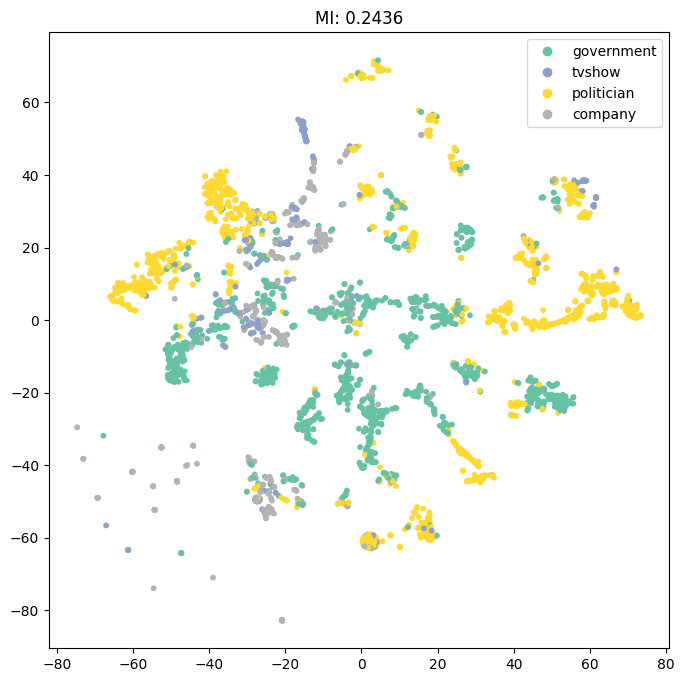

In [32]:
decomposition = TSNE(n_components=2)
xy_emb = decomposition.fit_transform(emb)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(xy_emb[:, 0], xy_emb[:, 1], c=labels, s=10, cmap=plt.cm.Set2)
plt.legend(handles=scatter.legend_elements()[0], labels=unique)
plt.title(f'MI: {mi:.4f}');

## Task 3 MultiRankWalk (2 points)

Consider Zachary's Karate Club graph. Purple nodes - unlabeled, 3 nodes have labels (2 classes)

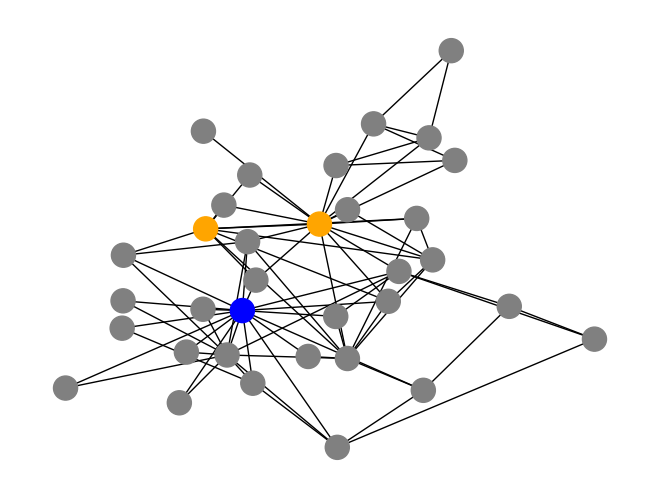

In [33]:
G = nx.karate_club_graph()
x_labeled = np.array([0, 1, 33])
x_unlabeled = np.array(list(set(G.nodes).difference(x_labeled)))
y_true = (np.array(list(nx.get_node_attributes(G, 'club').values())) == 'Officer').astype('int')
y_labeled = y_true[x_labeled]
y_unlabeled = y_true[x_unlabeled]

color = ['grey'] * len(G)
for i, node in enumerate(x_labeled): color[node] = 'blue' if y_labeled[i] else 'orange'

pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos=pos, node_color=color)

MultiRankWalk is a semi-supervised learning method that based on random graph walk. Basic idea is similar to personalized PageRank

$$r =\alpha P^T r + (1 - \alpha)v$$

where $v$ is a teleportation vector and $P$ is a transition matrix.
In this method, labeled nodes are described by a vector $v$ (non-zero values for labelled nodes of the class that we investigat, zeros for others).

For each class $c$, at every step the process may follow a transition with probability $\alpha$ or it may decide to teleport (start the process again at a node with label $c$) with probability $1 - \alpha$.

Repeat the process for every class and the class of an unlabeled node is decided by which class $c$'s process visited the instance most often.

Write function `personalized_pagerank_class_c` that performa the personalized pagerank for class $c$. The probabilities to teleport to the nodes with labels $c$ are the same. You may use pagerank from  `networkx`

In [34]:

# функция nx.pagerank внутри себя решает уравнение r = alpha * P^T * r + (1-alpha) * v.

def personalized_pagerank_class_c(G, y_labeled, x_labeled, c, alpha):

    # поиск "баз телепортации" (узлов нужного класса)
    mask_c = (y_labeled == c)

    # накладываем маску на массив x_labeled
    target_nodes = x_labeled[mask_c]

    # считаем, сколько всего у нас таких узлов (это наше k)
    num_targets = len(target_nodes)

    # NetworkX ожидает не массив NumPy, а словарь (dictionary)
    # Сначала создаем словарь, где каждому узлу графа присвоен строгий 0
    personalization_vector = {node: 0.0 for node in G.nodes()}

    # расспределяем вероятность поровну между найденными целевыми узлами
    for node in target_nodes:
        personalization_vector[node] = 1.0 / num_targets


    # alpha — вероятность пойти по ребру
    # personalization — подготовленный словарь, указывающий, куда телепортироваться
    pr_dict = nx.pagerank(G, alpha = alpha, personalization = personalization_vector)

    # pr_dict возвращает словарь {узел: вероятность}
    # мы проходимся циклом от 0 до количества узлов и вытаскиваем вероятности по порядку
    pr_array = np.array([pr_dict[i] for i in range(len(G.nodes()))])

    return pr_array

In [35]:
y_pred_0 = personalized_pagerank_class_c(G, y_labeled, x_labeled, c=0, alpha=0.6)
assert y_pred_0.shape == (34,)
assert np.allclose(y_pred_0.round(4)[:3], [0.2793, 0.2588, 0.0743])
assert np.allclose(personalized_pagerank_class_c(G, y_labeled, x_labeled, c=1, alpha=0.6).round(4)[:3], [0.0143, 0.0133, 0.0231])

Now implement `multirankwalk` that conducts personalized pagerank for all classes and returns classes for unlabeled nodes.

In [36]:
def multirankwalk(G, y_labeled, x_labeled, x_unlabeled, alpha):

    # np.unique оставляет только уникальные значения
    unique_classes = np.unique(y_labeled)

    # создаем пустое хранилище для векторов PageRank
    class_scores = []

    # запускаем  блуждателей
    for c in unique_classes:

        # вернет вектор вероятностей (длиной во весь граф, 34 элемента),
        # где высокие значения стоят у тех, кто структурно близок к классу c
        pr_vector = personalized_pagerank_class_c(G, y_labeled, x_labeled, c, alpha)

        # сохраняем этот вектор в наш список-хранилище
        class_scores.append(pr_vector)


    R_matrix = np.array(class_scores)
    R_matrix = R_matrix.T

    # фильтрация неизвестных
    unlabeled_scores = R_matrix[x_unlabeled]

    # выбор победителя (argmax)
    predicted_indices = np.argmax(unlabeled_scores, axis=1)

    y_pred_unlabeled = unique_classes[predicted_indices]

    return y_pred_unlabeled

In [37]:
y_pred = multirankwalk(G, y_labeled, x_labeled, x_unlabeled, alpha=0.8)
assert accuracy_score(y_unlabeled, y_pred) > 0.96

Text(0.5, 1.0, 'Prediction')

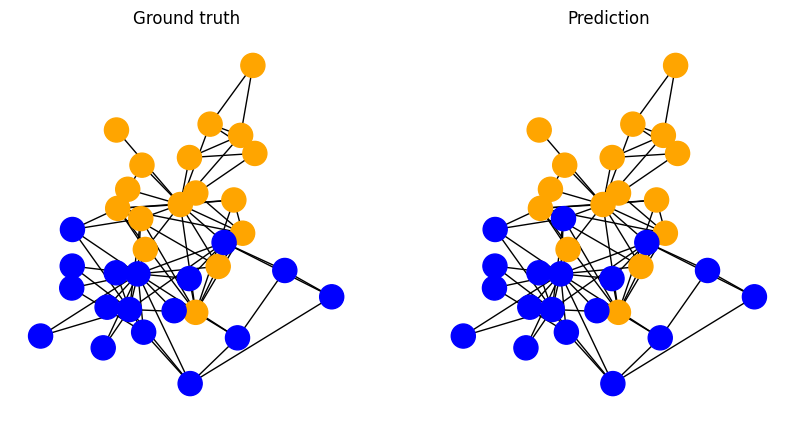

In [38]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2)

nx.draw(G, pos=pos, node_color=['blue' if l else 'orange' for l in y_true], ax=axs[0])
axs[0].set_title('Ground truth')

color = ['grey'] * len(G)
for i, node in enumerate(x_labeled): color[node] = 'blue' if y_labeled[i] else 'orange'
for i, node in enumerate(x_unlabeled): color[node] = 'blue' if y_pred[i] else 'orange'

nx.draw(G, pos=pos, node_color=color, ax=axs[1])
axs[1].set_title('Prediction')